# Notebook 1 

## Étape 1 : Import du dataset et EDA

Cette première étape a pour but de prendre connaissance du jeu de données fourni par *CurelyticsIA* avant toute transformation. On y vérifie la **structure des dossiers**, le **nombre d'images disponibles**, leur **résolution** et **leur mode de couleur**, ainsi que la **répartition** entre images labellisées et non labellisées.

Ces observations conditionnent les choix de preprocessing des étapes suivantes, notamment la compatibilité avec le modèle ResNet pré-entraîné.

### 1.1. Imports

Commençons par importer les packages nécessaires.

In [2]:
import os
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

### 1.2. Structure du dataset

On explore l'arborescence du dossier extrait du zip afin d'identifier comment les images sont organisées sur le disque.

Cette inspection permet de confirmer ou d'ajuster les hypothèses de structure avant d'écrire le code de comptage et de chargement des images.

In [3]:
DATA_DIR = Path("../data/mri_dataset_brain_cancer_oc")

assert DATA_DIR.exists(), f"Dossier introuvable : {DATA_DIR}, vérifie le chemin d'extraction du zip"

def lister_structure(root: Path, max_depth: int = 3):
    for path in sorted(root.rglob("*")):
        depth = len(path.relative_to(root).parts)
        if depth > max_depth:
            continue
        prefix = "  " * (depth - 1)
        marker = "/" if path.is_dir() else ""
        print(f"{prefix}{path.name}{marker}")

lister_structure(DATA_DIR)

mri_dataset_brain_cancer_oc/
  avec_labels/
    cancer/
    normal/
  Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt
  sans_label/
    001b158a-7af8-451e-bf31-3a9116265f3a.jpg
    00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg
    00455a62-f79f-4072-9a23-4951e759acdc.jpg
    004ce5f5-ca6b-490f-9b2f-c322c152e2ee.jpg
    005d9a37-8894-4eb5-8367-1015d4a43638.jpg
    009e9d31-9f37-4d97-a941-81501294c403.jpg
    009eac4a-c951-4da9-852a-b32e9ce20c6e.jpg
    00e9e198-79de-47ab-9f4e-7b76152324bb.jpg
    01274f5e-3064-4efd-af4b-38e164188c31.jpg
    01717fbf-4bcf-475a-a718-361ed07d2854.jpg
    01d1f0ed-5070-45a8-ad26-f8a95ebec98d.jpg
    01d4471e-7c83-4335-ab49-c650d0da1dea.jpg
    01e09766-fcd9-4df0-82f7-265f9ffecdf6.jpg
    01f4b8d2-56ed-4d82-ad41-6864de091425.jpg
    01fa1329-7524-49f5-8f11-bb9d8717a3fe.jpg
    0208c07c-bc4b-4741-ad0f-d5beeb18cc52.jpg
    02af8a8e-3c79-4a3c-8412-52f483eb9411.jpg
    02d2c771-7bf5-4771-972c-7f123088b7b0.jpg
    0303753e-919b-4947-8e55-4fc922bfbe

le dataset est organisé en deux grandes branches, `avec_labels/` contenant deux sous-dossiers `cancer` et `normal` correspondant aux annotations des radiologues, et `sans_label/` regroupant les images non annotées à plat, sans sous-catégorie.

Cette organisation confirme l'hypothèse de départ et valide l'usage du nom de dossier parent comme proxy de label pour la suite de l'analyse.

### 1.3. Recensement des images et formats

On liste ici l'ensemble des fichiers images du dataset, tous sous-dossiers confondus, et on relève les extensions de fichiers rencontrées.

Cette étape sert de vérification de cohérence : le total obtenu est comparé au volume annoncé dans la documentation du dataset.

In [4]:
extensions_valides = {".png", ".jpg", ".jpeg"}
fichiers_images = [p for p in DATA_DIR.rglob("*") if p.suffix.lower() in extensions_valides]

print(f"Nombre total d'images trouvées : {len(fichiers_images)}")

extensions_trouvees = Counter(p.suffix.lower() for p in fichiers_images)
print(f"Formats rencontrés : {dict(extensions_trouvees)}")

Nombre total d'images trouvées : 1506
Formats rencontrés : {'.jpg': 1506}


le dataset contient 1506 images, toutes au format `.jpg`, un format unique. C'est une bonne nouvelle pour la suite : pas besoin de gérer une conversion de format inter-fichiers avant le preprocessing.

Le total de 1506 est légèrement supérieur aux 1500 images annoncées dans la documentation du dataset (écart de 6 images), à noter comme observation mineure sans impact sur la suite.

### 1.4. Résolution et canaux de couleur (échantillon)

On ouvre un échantillon d'images pour en extraire la largeur, la hauteur et le mode de couleur (niveaux de gris ou RGB).

L'objectif est de savoir si les images sont homogènes ou s'il faudra prévoir un redimensionnement et une conversion de canaux avant de les passer dans un modèle pré-entraîné.

In [5]:
def inspecter_image(path: Path) -> dict:
    with Image.open(path) as img:
        return {
            "chemin": str(path.relative_to(DATA_DIR)),
            "largeur": img.width,
            "hauteur": img.height,
            "mode": img.mode,
        }

echantillon = fichiers_images if len(fichiers_images) <= 200 else np.random.choice(
    fichiers_images, size=200, replace=False
)

infos = pd.DataFrame([inspecter_image(p) for p in echantillon])

print("Résolutions rencontrées :")
print(infos.groupby(["largeur", "hauteur"]).size())

print("\nModes de couleur rencontrés (canaux) :")
print(infos["mode"].value_counts())

Résolutions rencontrées :
largeur  hauteur
512      512        200
dtype: int64

Modes de couleur rencontrés (canaux) :
mode
RGB    200
Name: count, dtype: int64


Sur l'échantillon de 200 images inspectées, la résolution est parfaitement homogène à 512×512 pixels, conforme à la documentation du dataset.

Le mode de couleur est également homogène, RGB sur les 200 images, aucune image en niveaux de gris.

C'est une bonne nouvelle pour l'étape 2 : pas de redimensionnement hétérogène ni de conversion de canaux à gérer avant l'extraction de features avec ResNet, qui attend justement des images RGB.

### 1.5. Comptage des labels

La structure observée distingue trois sous-ensembles : `avec_labels/cancer/`, `avec_labels/normal/` pour les images annotées par les radiologues, et `sans_label/` pour le reste.

On compte ici le nombre d'images dans chaque sous-dossier afin de vérifier la répartition entre données fortement labellisées et données à labelliser par la suite.

In [6]:
def compter_par_dossier_parent(fichiers: list[Path]) -> Counter:
    return Counter(p.parent.name for p in fichiers)

comptage = compter_par_dossier_parent(fichiers_images)
print("Comptage d'images par dossier parent (proxy du label) :")
for dossier, n in comptage.items():
    print(f"  {dossier} : {n}")

Comptage d'images par dossier parent (proxy du label) :
  cancer : 50
  normal : 50
  sans_label : 1406


le jeu labellisé compte 100 images, réparties de façon parfaitement équilibrée entre `cancer` (50) et `normal` (50), un point favorable puisqu'**il évite un biais de classe** sur le jeu fortement labellisé qui servira au calcul du score ARI.

Le jeu non labellisé compte 1406 images (93 % du dataset total), qui seront labellisées faiblement par clustering aux étapes suivantes.

### 1.6. Exemples visuels, un échantillon équilibré par label

Un tirage purement aléatoire sur l'ensemble du dataset donnerait quasi uniquement des images non labellisées, puisqu'elles représentent la grande majorité des 1506 images.

On force donc ici un échantillon équilibré, avec des exemples issus de chaque catégorie (`cancer`, `normal`, `sans_label`), pour avoir un aperçu visuel représentatif des trois populations.

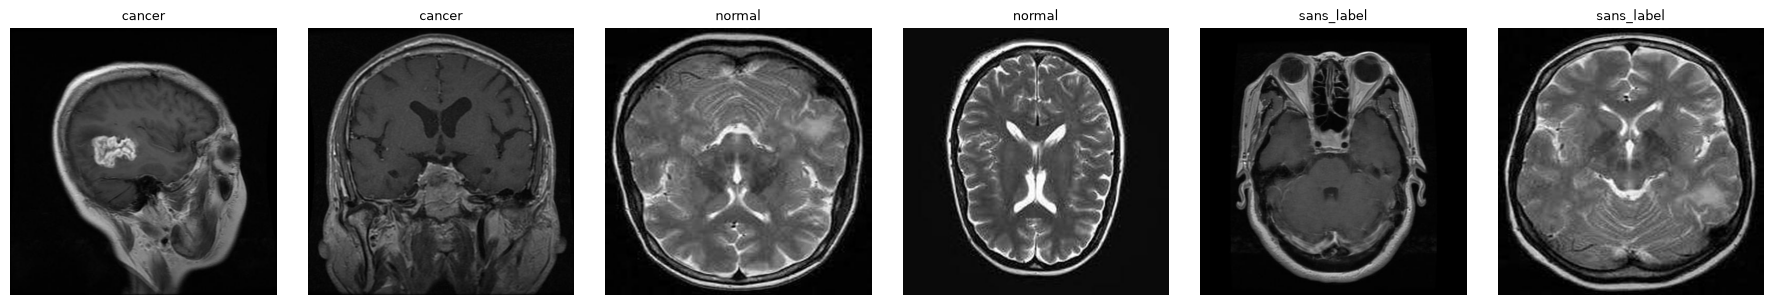

In [9]:
# On force un mix : quelques cancer, quelques normal, quelques sans_label
fichiers_cancer = [p for p in fichiers_images if p.parent.name == "cancer"]
fichiers_normal = [p for p in fichiers_images if p.parent.name == "normal"]
fichiers_sans_label = [p for p in fichiers_images if p.parent.name == "sans_label"]

n_par_groupe = 2
exemples = (
    list(np.random.choice(fichiers_cancer, size=min(n_par_groupe, len(fichiers_cancer)), replace=False))
    + list(np.random.choice(fichiers_normal, size=min(n_par_groupe, len(fichiers_normal)), replace=False))
    + list(np.random.choice(fichiers_sans_label, size=min(n_par_groupe, len(fichiers_sans_label)), replace=False))
)

fig, axes = plt.subplots(1, len(exemples), figsize=(3 * len(exemples), 3))
for ax, chemin in zip(axes, exemples):
    with Image.open(chemin) as img:
        ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(chemin.parent.name, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Étape 2 : Preprocessing

Cette étape prépare les images pour l'extraction de features avec un modèle ResNet pré-entraîné.

On vérifie d'abord l'absence d'outliers sur l'ensemble du dataset (fichiers corrompus, tailles ou modes de couleur hétérogènes non détectés dans l'échantillon précédent), puis on définit le pipeline de redimensionnement et de normalisation attendu par ResNet.

### 2.1. Nettoyage et détection d'outliers sur l'ensemble du dataset

L'EDA portait sur un échantillon de 200 images. On passe ici en revue les 1506 images pour s'assurer qu'aucun fichier n'est corrompu, illisible, ou de taille/mode différent de la norme observée (512×512, RGB), avant de lancer un preprocessing en masse.

In [10]:
def verifier_image(path: Path) -> dict:
    """Tente d'ouvrir l'image et retourne ses caractéristiques, ou une erreur si corrompue."""
    try:
        with Image.open(path) as img:
            img.verify()  # vérifie l'intégrité du fichier sans le charger entièrement
        with Image.open(path) as img:  # verify() invalide l'objet, on rouvre pour lire les attributs
            return {
                "chemin": str(path.relative_to(DATA_DIR)),
                "largeur": img.width,
                "hauteur": img.height,
                "mode": img.mode,
                "corrompue": False,
                "erreur": None,
            }
    except Exception as e:
        return {
            "chemin": str(path.relative_to(DATA_DIR)),
            "largeur": None,
            "hauteur": None,
            "mode": None,
            "corrompue": True,
            "erreur": str(e),
        }

# Vérification sur l'ensemble du dataset (peut prendre quelques minutes selon la machine)
verification_complete = pd.DataFrame([verifier_image(p) for p in fichiers_images])

n_corrompues = verification_complete["corrompue"].sum()
print(f"Images corrompues détectées : {n_corrompues}")

if n_corrompues > 0:
    print(verification_complete[verification_complete["corrompue"]])

resolutions_hors_norme = verification_complete[
    (verification_complete["corrompue"] == False)
    & ((verification_complete["largeur"] != 512) | (verification_complete["hauteur"] != 512))
]
print(f"\nImages avec une résolution différente de 512x512 : {len(resolutions_hors_norme)}")

modes_hors_norme = verification_complete[
    (verification_complete["corrompue"] == False) & (verification_complete["mode"] != "RGB")
]
print(f"Images avec un mode de couleur différent de RGB : {len(modes_hors_norme)}")

Images corrompues détectées : 0

Images avec une résolution différente de 512x512 : 0
Images avec un mode de couleur différent de RGB : 0


**Aucune anomalie détectée sur l'ensemble des 1506 images**.

Aucun fichier corrompu, aucune résolution différente de 512×512, aucun mode de couleur différent de RGB.

L'homogénéité observée sur l'échantillon de 200 images à l'étape précédente se confirme donc sur la totalité du dataset, **le jeu de données ne nécessite pas de nettoyage préalable**.

### 2.2. Pipeline de redimensionnement et normalisation

ResNet pré-entraîné sur ImageNet attend des images en 224×224 pixels, avec une normalisation spécifique (moyenne et écart-type calculés sur ImageNet).

On définit ici les transformations correspondantes avec `torchvision.transforms`, qui seront réutilisées telles quelles à l'étape d'extraction de features.

In [11]:
from torchvision import transforms

# Valeurs standard ImageNet, attendues par les modèles ResNet pré-entraînés
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

preprocessing_resnet = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Test rapide sur une image pour valider le pipeline
image_test = Image.open(fichiers_images[0]).convert("RGB")
tenseur_test = preprocessing_resnet(image_test)
print(f"Forme du tenseur après preprocessing : {tenseur_test.shape}")
print(f"Valeurs min/max après normalisation : {tenseur_test.min():.3f} / {tenseur_test.max():.3f}")

Forme du tenseur après preprocessing : torch.Size([3, 224, 224])
Valeurs min/max après normalisation : -2.118 / 2.274


Le pipeline de redimensionnement et normalisation fonctionne comme attendu, le tenseur obtenu a la forme `[3, 224, 224]`, conforme au format d'entrée de ResNet (3 canaux RGB, 224×224 pixels).

Les valeurs normalisées s'étendent de -2,118 à 2,274, une plage cohérente avec une normalisation ImageNet standard (les valeurs négatives sont normales, elles correspondent aux pixels sous la moyenne du dataset ImageNet).

**Le pipeline est validé** et prêt à être appliqué sur l'ensemble des images à l'étape d'extraction de features.